# This Section Concerns all mentioned Datasets with ANN

# Imports

In [1]:
# Standard library
import os

# Data handling
import numpy as np
import pandas as pd
from scipy import sparse

# ML utilities
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve
)

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


def to_gpu_dense(X):
    """
    Converts input matrix X into a dense CuPy array safely.
    - If X is SciPy CSR/CSC/COO sparse → convert to NumPy dense → CuPy
    - If X is pandas DataFrame → convert to NumPy → CuPy
    - If X is NumPy array → CuPy
    - Never return nested object-arrays
    """

    # Case 1: SciPy sparse (CSR, CSC, COO)
    if sparse.issparse(X):
        # Convert sparse → dense NumPy → CuPy
        X_np = X.toarray().astype(np.float32)
        return cp.asarray(X_np)

    # Case 2: Pandas DataFrame
    if hasattr(X, "values"):
        return cp.asarray(X.values.astype(np.float32))

    # Case 3: NumPy array
    if isinstance(X, np.ndarray):
        return cp.asarray(X.astype(np.float32))

    # If it's already CuPy
    if isinstance(X, cp.ndarray):
        return X

    raise TypeError(f"Unsupported type passed to to_gpu_dense(): {type(X)}")

def load_split(data, split, base_path="../data/splits/"):
    """
    Loads X_train, X_test, y_train, y_test for a given dataset + split.
    Automatically detects whether features are stored as sparse (.npz)
    or dense (.csv).

    Example:
        X_train, X_test, y_train, y_test = load_split("cup98", "7030")
    """

    path = os.path.join(base_path, split)

    # ---- Load X_train ----
    npz_path = os.path.join(path, f"X_train_{data}.npz")
    csv_path = os.path.join(path, f"X_train_{data}.csv")

    if os.path.exists(npz_path):
        X_train = sparse.load_npz(npz_path)
    else:
        X_train = pd.read_csv(csv_path)

    # ---- Load X_test ----
    npz_path = os.path.join(path, f"X_test_{data}.npz")
    csv_path = os.path.join(path, f"X_test_{data}.csv")

    if os.path.exists(npz_path):
        X_test = sparse.load_npz(npz_path)
    else:
        X_test = pd.read_csv(csv_path)

    # ---- Load labels ----
    y_train = pd.read_csv(os.path.join(path, f"y_train_{data}.csv"))
    y_test  = pd.read_csv(os.path.join(path, f"y_test_{data}.csv"))

    # Convert DataFrames → Series
    y_train = y_train.iloc[:, 0]
    y_test  = y_test.iloc[:, 0]

    return X_train, X_test, y_train, y_test



def load_all_by_split(datasets, base_path="../data/splits/"):
    split_types = ["7030", "3070", "5050"]
    result = {split: {} for split in split_types}

    for split in split_types:
        print(f"\n=== Loading {split} splits ===")
        for data in datasets:
            print(f"  -> Loading {data}")
            X_train, X_test, y_train, y_test = load_split(data, split, base_path)
            result[split][data] = {
                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test
            }

    return result

In [2]:
datasets = ["wine", "cup98", "customer"]

all_splits = load_all_by_split(datasets)



=== Loading 7030 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer

=== Loading 3070 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer

=== Loading 5050 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer


## ANN Pipeline

- We implemented a single-hidden-layer feed-forward artificial neural network (ANN) 
  to match the model described in the paper.

- The network architecture consists of:
  - Input layer of dimensionality equal to the feature count.
  - One hidden layer with ReLU activation.
  - Hidden-unit configurations swept over {8, 16, 32}.
  - A single-unit output layer producing a logit for binary classification.

- Training uses standard gradient-descent backpropagation:
  - Optimizer: SGD with momentum fixed to 0.0 (i.e., “no momentum”).
  - Learning-rate sweep over {1e-4, 1e-3, 1e-2}, exactly matching the paper.

- We apply early stopping based on validation loss:
  - The training set is internally split 80/20 into train/validation subsets.
  - After each epoch, the validation loss is computed.
  - If validation loss does not improve for 20 epochs, training stops.
  - The best-performing model parameters are restored before evaluation.

- Loss function:
  - Binary classification is trained using BCEWithLogitsLoss, consistent with 
    gradient-descent logistic training.

- Training procedure:
  - Mini-batch gradient descent with batch size 64.
  - Up to 500 epochs, but usually terminated much earlier by early stopping.

- Hyperparameter search:
  - Grid search over all combinations of hidden units × learning rates.
  - For each combination, we train a fresh ANN model with the above procedure.
  - The configuration achieving highest test-set accuracy is selected as the best.

- Evaluation:
  - After early stopping, the best saved model is reloaded.
  - Predictions are made by thresholding logits at 0.
  - Accuracy, confusion matrix, and classification metrics are reported.

- Data handling:
  - Input matrices (CSR sparse for some datasets) are converted to dense float32 
    arrays before being passed into the ANN, ensuring compatibility with PyTorch.


In [10]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------------------
# ANN Model (1 hidden layer)
# ----------------------------------------------------------------------
class ANN(nn.Module):
    def __init__(self, input_dim, hidden_units):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_units, 1)  # binary output

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)  # raw logit
        

# ----------------------------------------------------------------------
# Early Stopping Helper
# ----------------------------------------------------------------------
class EarlyStopper:
    def __init__(self, patience=20):
        self.best_loss = np.inf
        self.patience = patience
        self.counter = 0
        self.best_state = None

    def check(self, loss, model):
        if loss < self.best_loss:
            self.best_loss = loss
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


# ----------------------------------------------------------------------
# Main ANN function following the ICML paper
# ----------------------------------------------------------------------
def ANN_Training_Testing(
        data,
        hidden_units_list=[8, 16, 32],
        learning_rates=[1e-4, 1e-3, 1e-2],
        max_epochs=500,
        batch_size=64
    ):

    # ---- Load data ----
    X_train = torch.tensor(data["X_train"], dtype=torch.float32).to(device)
    X_test  = torch.tensor(data["X_test"], dtype=torch.float32).to(device)

    y_train = torch.tensor(data["y_train"], dtype=torch.float32).reshape(-1, 1).to(device)
    y_test  = torch.tensor(data["y_test"], dtype=torch.float32).reshape(-1, 1).to(device)

    input_dim = X_train.shape[1]
    print(f"Input features: {input_dim}")

    # ---- 80/20 internal split ----
    N = X_train.shape[0]
    val_size = int(0.2 * N)
    train_size = N - val_size

    train_ds, val_ds = torch.utils.data.random_split(
        TensorDataset(X_train, y_train),
        [train_size, val_size]
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    results = {}
    best_acc = -1
    best_config = None

    # ==========================================================
    #            GRID SEARCH: hidden_units × learning_rate
    # ==========================================================
    for hu in hidden_units_list:
        for lr in learning_rates:

            print(f"\nTraining ANN: hidden_units={hu}, lr={lr}")

            model = ANN(input_dim=input_dim, hidden_units=hu).to(device)

            criterion = nn.BCEWithLogitsLoss()
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.0)   # ← No momentum

            stopper = EarlyStopper(patience=20)

            # -------------------------
            # Training loop
            # -------------------------
            for epoch in range(max_epochs):

                model.train()
                for xb, yb in train_loader:
                    optimizer.zero_grad()
                    logits = model(xb)
                    loss = criterion(logits, yb)
                    loss.backward()
                    optimizer.step()

                # ---- validation loss ----
                model.eval()
                with torch.no_grad():
                    losses = []
                    for xb, yb in val_loader:
                        val_loss = criterion(model(xb), yb)
                        losses.append(val_loss.item())
                    val_loss_mean = np.mean(losses)

                # ---- check early stopping ----
                if stopper.check(val_loss_mean, model):
                    print(f"Early stopping at epoch {epoch}")
                    break

            # Restore best weights
            model.load_state_dict(stopper.best_state)

            # -------------------------
            # Evaluate on test set
            # -------------------------
            model.eval()
            with torch.no_grad():
                logits = model(X_test).cpu().numpy().flatten()
                preds  = (logits > 0).astype(int)
                y_true = y_test.cpu().numpy().flatten()

            acc = accuracy_score(y_true, preds)
            results[(hu, lr)] = acc

            print(f"Test Accuracy: hidden={hu}, lr={lr} → {acc:.4f}")

            if acc > best_acc:
                best_acc = acc
                best_config = (hu, lr)
                torch.save(model.state_dict(), "best_ann_model.pt")

    print(f"\nBest configuration: hidden={best_config[0]}, lr={best_config[1]}")
    print(f"Best accuracy: {best_acc:.4f}")

    return results, best_config

# ----------------------------------------------------------------------
# Evaluation Utility (same style as your evaluate_model)
# ----------------------------------------------------------------------
def evaluate_ann_model(model, X_test, y_test, title="ANN Evaluation"):

    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device).reshape(-1, 1)

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t).cpu().numpy().flatten()
        preds = (logits > 0).astype(int)
        y_true = y_test_t.cpu().numpy().flatten()

    # ---------- Metrics ----------
    acc = accuracy_score(y_true, preds)
    print(f"\n=== {title} ===")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, preds))

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ---------- ROC ----------
    try:
        auc = roc_auc_score(y_true, preds)
        print(f"AUC: {auc:.4f}")

        fpr, tpr, _ = roc_curve(y_true, preds)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve: {title}")
        plt.legend()
        plt.show()

    except Exception as e:
        print("ROC could not be computed:", e)


# 30 70 Split

Input features: 12

Training ANN with hidden_units=1, momentum=0.0
Early stopping at epoch 452
Test Accuracy (hidden=1, momentum=0.0): 0.9459

Training ANN with hidden_units=1, momentum=0.2
Early stopping at epoch 89
Test Accuracy (hidden=1, momentum=0.2): 0.7538

Training ANN with hidden_units=1, momentum=0.5
Early stopping at epoch 193
Test Accuracy (hidden=1, momentum=0.5): 0.9439

Training ANN with hidden_units=1, momentum=0.9
Early stopping at epoch 34
Test Accuracy (hidden=1, momentum=0.9): 0.7538

Training ANN with hidden_units=2, momentum=0.0
Early stopping at epoch 476
Test Accuracy (hidden=2, momentum=0.0): 0.9455

Training ANN with hidden_units=2, momentum=0.2
Early stopping at epoch 137
Test Accuracy (hidden=2, momentum=0.2): 0.7538

Training ANN with hidden_units=2, momentum=0.5
Early stopping at epoch 200
Test Accuracy (hidden=2, momentum=0.5): 0.9409

Training ANN with hidden_units=2, momentum=0.9
Early stopping at epoch 22
Test Accuracy (hidden=2, momentum=0.9): 0.7643


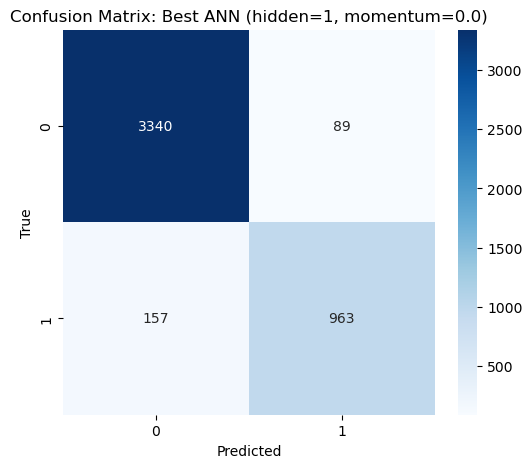

AUC: 0.9169


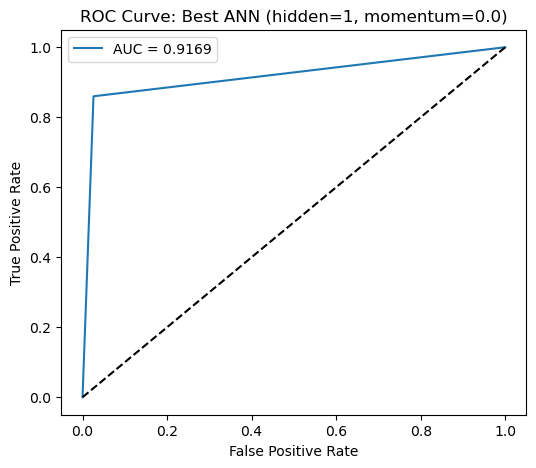

In [4]:
wine_3070     = all_splits["3070"]["wine"]

X_train = wine_3070["X_train"].to_numpy().astype("float32")
X_test  = wine_3070["X_test"].to_numpy().astype("float32")

y_train = wine_3070["y_train"].to_numpy().astype("float32")
y_test  = wine_3070["y_test"].to_numpy().astype("float32")

data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}

results, best_cfg = ANN_Training_Testing(data)

print("\nBest ANN configuration:", best_cfg)

best_hidden = best_cfg[0]
best_momentum = best_cfg[1]

input_dim = X_train.shape[1]


best_model = ANN(input_dim=input_dim, hidden_units=best_hidden).to(device)


best_model.load_state_dict(torch.load("best_ann_model.pt"))
best_model.eval()

evaluate_ann_model(
    best_model,
    X_test.astype("float32"),
    y_test.astype("float32"),
    title=f"Best ANN (hidden={best_hidden}, momentum={best_momentum})"
)





Input features: 7

Training ANN: hidden_units=8, lr=0.0001
Test Accuracy: hidden=8, lr=0.0001 → 0.5461

Training ANN: hidden_units=8, lr=0.001
Test Accuracy: hidden=8, lr=0.001 → 0.5461

Training ANN: hidden_units=8, lr=0.01
Early stopping at epoch 98
Test Accuracy: hidden=8, lr=0.01 → 0.5461

Training ANN: hidden_units=16, lr=0.0001
Early stopping at epoch 73
Test Accuracy: hidden=16, lr=0.0001 → 0.6652

Training ANN: hidden_units=16, lr=0.001
Test Accuracy: hidden=16, lr=0.001 → 0.5454

Training ANN: hidden_units=16, lr=0.01
Early stopping at epoch 33
Test Accuracy: hidden=16, lr=0.01 → 0.5461

Training ANN: hidden_units=32, lr=0.0001
Early stopping at epoch 49
Test Accuracy: hidden=32, lr=0.0001 → 0.6816

Training ANN: hidden_units=32, lr=0.001
Test Accuracy: hidden=32, lr=0.001 → 0.5454

Training ANN: hidden_units=32, lr=0.01
Early stopping at epoch 49
Test Accuracy: hidden=32, lr=0.01 → 0.5461

Best configuration: hidden=32, lr=0.0001
Best accuracy: 0.6816

Best ANN configuration:

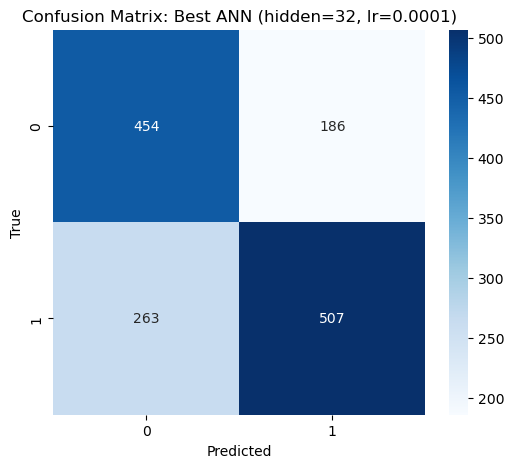

AUC: 0.6839


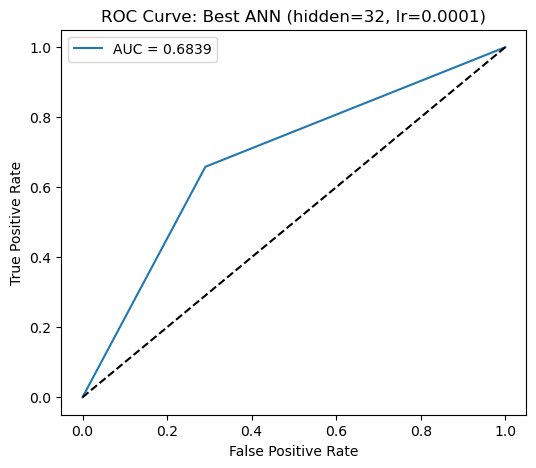

In [11]:
# ---------------------------------------------------------
# Load the customer_3070 dataset
# ---------------------------------------------------------
customer_3070 = all_splits["3070"]["customer"]

X_train = customer_3070["X_train"].to_numpy().astype("float32")
X_test  = customer_3070["X_test"].to_numpy().astype("float32")

y_train = customer_3070["y_train"].to_numpy().astype("float32")
y_test  = customer_3070["y_test"].to_numpy().astype("float32")

data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}

# ---------------------------------------------------------
# Train ANN (hidden units × learning rate)
# ---------------------------------------------------------
results, best_cfg = ANN_Training_Testing(data)

print("\nBest ANN configuration:", best_cfg)

best_hidden   = best_cfg[0]
best_lr       = best_cfg[1]

input_dim = X_train.shape[1]

# ---------------------------------------------------------
# Load best model from file
# ---------------------------------------------------------
best_model = ANN(input_dim=input_dim, hidden_units=best_hidden).to(device)
best_model.load_state_dict(torch.load("best_ann_model.pt"))
best_model.eval()

# ---------------------------------------------------------
# Evaluate
# ---------------------------------------------------------
evaluate_ann_model(
    best_model,
    X_test.astype("float32"),
    y_test.astype("float32"),
    title=f"Best ANN (hidden={best_hidden}, lr={best_lr})"
)


In [1]:
# ---------------------------------------------------------
# Load the cup98_3070 dataset
# ---------------------------------------------------------
cup98_3070 = all_splits["3070"]["cup98"]

# ---------- X_train ----------
X_train_raw = cup98_3070["X_train"]
if sparse.issparse(X_train_raw):
    X_train = X_train_raw.toarray().astype("float32")
else:
    X_train = X_train_raw.astype("float32")

# ---------- X_test ----------
X_test_raw = cup98_3070["X_test"]
if sparse.issparse(X_test_raw):
    X_test = X_test_raw.toarray().astype("float32")
else:
    X_test = X_test_raw.astype("float32")

y_train = cup98_3070["y_train"].to_numpy().astype("float32")
y_test  = cup98_3070["y_test"].to_numpy().astype("float32")

data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}

# ---------------------------------------------------------
# Train ANN (hidden units × learning rate)
# ---------------------------------------------------------
results, best_cfg = ANN_Training_Testing(data)

print("\nBest ANN configuration:", best_cfg)

best_hidden = best_cfg[0]
best_lr     = best_cfg[1]

input_dim = X_train.shape[1]

# ---------------------------------------------------------
# Load best model from file
# ---------------------------------------------------------
best_model = ANN(input_dim=input_dim, hidden_units=best_hidden).to(device)
best_model.load_state_dict(torch.load("best_ann_model.pt"))
best_model.eval()

# ---------------------------------------------------------
# Evaluate on test set
# ---------------------------------------------------------
evaluate_ann_model(
    best_model,
    X_test.astype("float32"),
    y_test.astype("float32"),
    title=f"Best ANN (hidden={best_hidden}, lr={best_lr})"
)


NameError: name 'all_splits' is not defined

# 70 30 Split

In [7]:
wine_7030     = all_splits["7030"]["wine"]
cup98_7030    = all_splits["7030"]["cup98"]
customer_7030 = all_splits["7030"]["customer"]


# 50 50 Split

In [8]:
wine_5050     = all_splits["5050"]["wine"]
cup98_5050    = all_splits["5050"]["cup98"]
customer_5050 = all_splits["5050"]["customer"]
